In [1]:
### The goal here is to build a toy dataset that validates the CWoLa approach, specifically the ability
### to compare inputs across two mixed samples (weakly supervised) and output a score that ranks the event 
### more similar to the signal region of 1 or more similar to the background region of 0. 

### explore limits of CWoLa: signal vs no signal, signal region definition misaligned
### view loss and accuracy plots

### AUC metric quantifies performance in original CWoLa paper

### ratios of each mixed sample not necessary for CWoLa, remains equal within sets

In [2]:
import torch

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
# define data, 6-D space

background_events = 8000
signal_events = 2000

# background distribution
Xb = np.random.uniform(low=-10, high=10, size=(background_events, 6))
Xb = np.array(Xb, dtype=np.float32)
yb = np.zeros((len(Xb), 1), dtype=np.float32)

Xb_train, Xb_valtest, yb_train, yb_valtest = train_test_split(Xb, yb, test_size = 0.2)
Xb_val, Xb_test, yb_val, yb_test = train_test_split(Xb_valtest, yb_valtest, test_size=0.5)


# signal distribution
mu_s = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
cov_s = np.eye(6) # identity matrix for covariance
Xs = np.random.multivariate_normal(mu_s, cov_s, size=signal_events)
Xs = np.array(Xs, dtype=np.float32)
ys = np.ones((len(Xs), 1), dtype=np.float32)

Xs_train, Xs_valtest, ys_train, ys_valtest = train_test_split(Xs, ys, test_size = 0.2)
Xs_val, Xs_test, ys_val, ys_test = train_test_split(Xs_valtest, ys_valtest, test_size=0.5)

# guarantees that training, validation, and test have the same percentage of background vs signal points (90/10)
print(f"Background training set has {len(Xb_train)} events.")
print(f"Background validation set has {len(Xb_val)} events.")
print(f"Background test set has {len(Xb_test)} events.")
print(f"Signal training set has {len(Xs_train)} events.")
print(f"Signal validation set has {len(Xs_val)} events.")
print(f"Signal test set has {len(Xs_test)} events.")

X_train = np.vstack([Xb_train, Xs_train])
X_val = np.vstack([Xb_val, Xs_val])
X_test = np.vstack([Xb_test, Xs_test])
y_train = np.concatenate([yb_train, ys_train])
y_val = np.concatenate([yb_val, ys_val])
y_test = np.concatenate([yb_test, ys_test])

idx = np.random.permutation(len(X_train))
X_train = X_train[idx]
y_train = y_train[idx]

idx = np.random.permutation(len(X_val))
X_val = X_val[idx]
y_val = y_val[idx]

idx = np.random.permutation(len(X_test))
X_test = X_test[idx]
y_test = y_test[idx]

Background training set has 6400 events.
Background validation set has 800 events.
Background test set has 800 events.
Signal training set has 1600 events.
Signal validation set has 200 events.
Signal test set has 200 events.


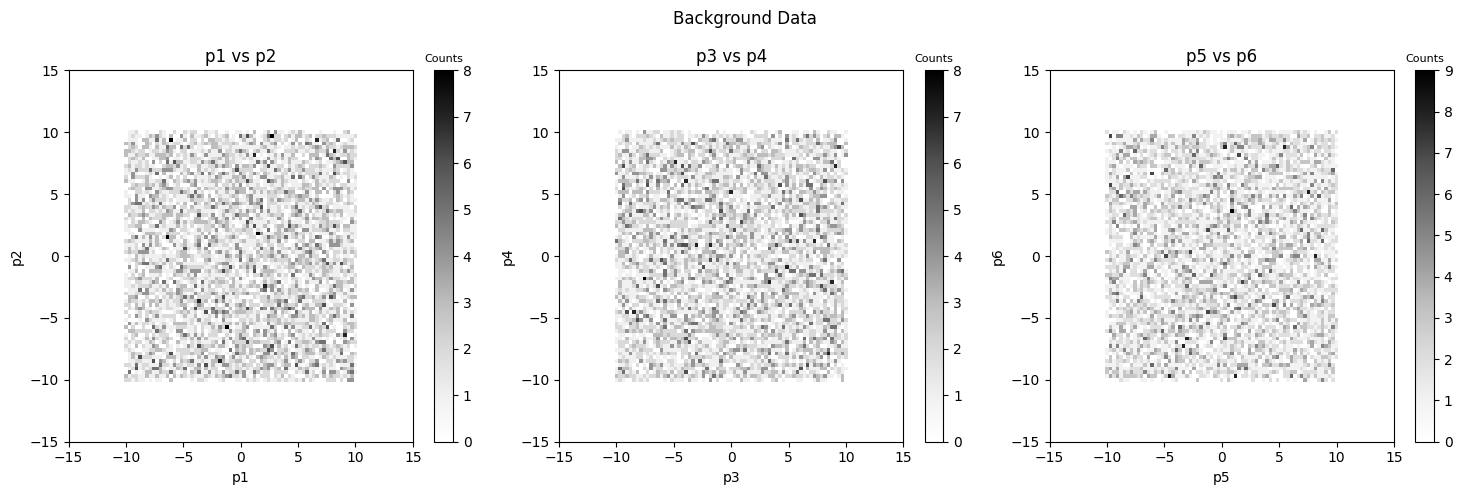

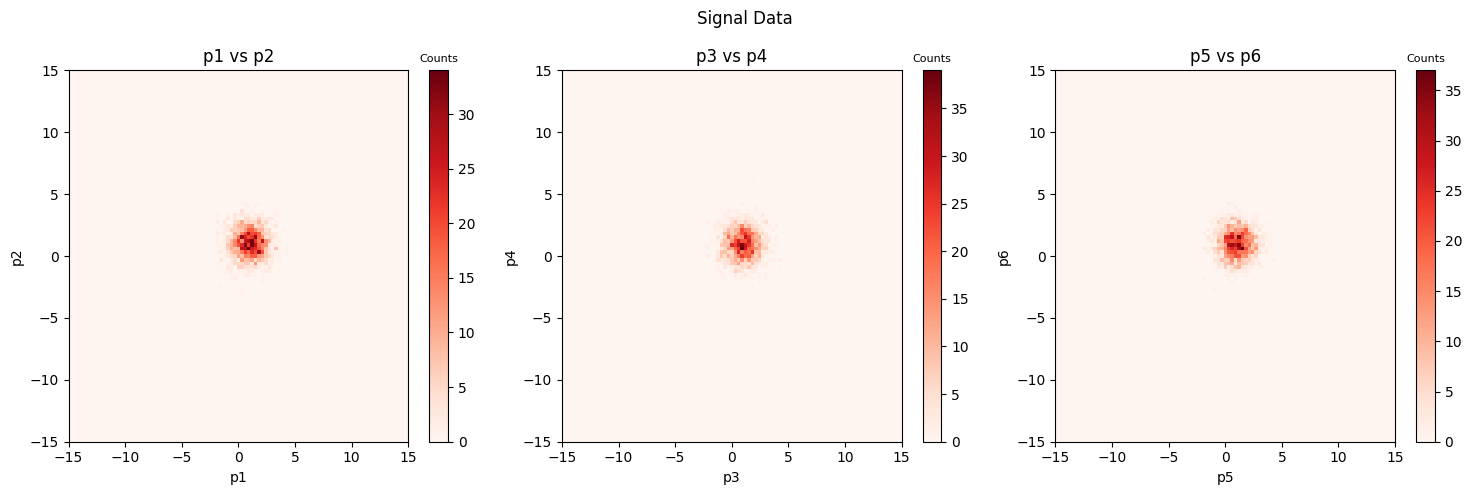

In [5]:
# DataFrames and plots

## background data

col_names = ['p1', 'p2', 'p3', 'p4', 'p5', 'p6']
df_background = pd.DataFrame(Xb, columns=col_names)
bins = [np.linspace(-15,15,100), np.linspace(-15,15,100)]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), tight_layout=True)
fig.suptitle('Background Data')
color = 'Greys'

h = axes[0].hist2d(df_background['p1'], df_background['p2'],
                   bins=bins, cmap=color)
axes[0].set_title('p1 vs p2')
axes[0].set_xlabel('p1', fontsize=10)
axes[0].set_ylabel('p2', fontsize=10)
c = fig.colorbar(h[3], ax=axes[0])
c.ax.set_title('Counts', fontsize=8)

h = axes[1].hist2d(df_background['p3'], df_background['p4'],
                   bins=bins, cmap=color)
axes[1].set_title('p3 vs p4')
axes[1].set_xlabel('p3', fontsize=10)
axes[1].set_ylabel('p4', fontsize=10)
c = fig.colorbar(h[3], ax=axes[1])
c.ax.set_title('Counts', fontsize=8)

h = axes[2].hist2d(df_background['p5'], df_background['p6'],
                   bins=bins, cmap=color)
axes[2].set_title('p5 vs p6')
axes[2].set_xlabel('p5', fontsize=10)
axes[2].set_ylabel('p6', fontsize=10)
c = fig.colorbar(h[3], ax=axes[2])
c.ax.set_title('Counts', fontsize=8)

plt.show()


## signal data

col_names = ['p1', 'p2', 'p3', 'p4', 'p5', 'p6']
df_signal = pd.DataFrame(Xs, columns=col_names)


fig, axes = plt.subplots(1, 3, figsize=(15, 5), tight_layout=True)
fig.suptitle('Signal Data')
color = 'Reds'

h = axes[0].hist2d(df_signal['p1'], df_signal['p2'],
                   bins=bins, cmap=color)
axes[0].set_title('p1 vs p2')
axes[0].set_xlabel('p1', fontsize=10)
axes[0].set_ylabel('p2', fontsize=10)
c = fig.colorbar(h[3], ax=axes[0])
c.ax.set_title('Counts', fontsize=8)

h = axes[1].hist2d(df_signal['p3'], df_signal['p4'],
                   bins=bins, cmap=color)
axes[1].set_title('p3 vs p4')
axes[1].set_xlabel('p3', fontsize=10)
axes[1].set_ylabel('p4', fontsize=10)
c = fig.colorbar(h[3], ax=axes[1])
c.ax.set_title('Counts', fontsize=8)

h = axes[2].hist2d(df_signal['p5'], df_signal['p6'],
                   bins=bins, cmap=color)
axes[2].set_title('p5 vs p6')
axes[2].set_xlabel('p5', fontsize=10)
axes[2].set_ylabel('p6', fontsize=10)
c = fig.colorbar(h[3], ax=axes[2])
c.ax.set_title('Counts', fontsize=8)

plt.show()

Signal Parameter p6 median =  0.97526705
Signal Parameter p6 standard deviation =  1.0000308


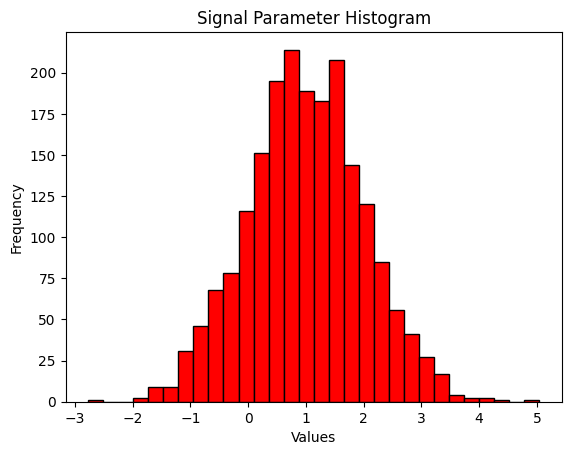

Signal Region Range:  -1.0247945  to  2.9753284


In [6]:
# define signal and sideband regions

signal_parameter = df_signal['p6']

p6_median = np.median(signal_parameter)
p6_std = np.std(signal_parameter)
print('Signal Parameter p6 median = ', p6_median)
print('Signal Parameter p6 standard deviation = ', p6_std)

plt.hist(signal_parameter, bins=30, color='red', edgecolor='black')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Signal Parameter Histogram')
plt.show()

# signal region will be defined as 1.5 standard deviations away from the median
sig_reg_low = p6_median - (2 * p6_std)
sig_reg_high = p6_median + (2 * p6_std)
print('Signal Region Range: ', sig_reg_low, ' to ', sig_reg_high)

In [7]:
## ensure event[5] matches with dataframe's p6

# print(X_train)
# print(df_background.head())

# for event in X_test:
#     if event[5] > -1.14689 and event[5] < -1.14688:
#         print(event)
#     else:
#         continue

In [8]:
# update train, val, test sets to have region labels

X_train_background_region = []
X_train_signal_region = []
X_val_background_region = []
X_val_signal_region = []
X_test_background_region = []
X_test_signal_region = []

for event in X_train:
    if event[5] < sig_reg_low or event[5] > sig_reg_high:
        X_train_background_region.append(event)
    else:
        X_train_signal_region.append(event)
for event in X_val:
    if event[5] < sig_reg_low or event[5] > sig_reg_high:
        X_val_background_region.append(event)
    else:
        X_val_signal_region.append(event)
for event in X_test:
    if event[5] < sig_reg_low or event[5] > sig_reg_high:
        X_test_background_region.append(event)
    else:
        X_test_signal_region.append(event)

X_train_background_region = np.array(X_train_background_region)
X_train_signal_region = np.array(X_train_signal_region)
X_val_background_region = np.array(X_val_background_region)
X_val_signal_region = np.array(X_val_signal_region)
X_test_background_region = np.array(X_test_background_region)
X_test_signal_region = np.array(X_test_signal_region)

y_train_background_region = np.zeros((len(X_train_background_region), 1), dtype=np.float32)
y_train_signal_region = np.ones((len(X_train_signal_region), 1), dtype=np.float32)
y_val_background_region = np.zeros((len(X_val_background_region), 1), dtype=np.float32)
y_val_signal_region = np.ones((len(X_val_signal_region), 1), dtype=np.float32)
y_test_background_region = np.zeros((len(X_val_background_region), 1), dtype=np.float32)
y_test_signal_region = np.ones((len(X_val_signal_region), 1), dtype=np.float32)

X_train_weak = np.vstack([X_train_background_region, X_train_signal_region]).astype(np.float32)
X_val_weak = np.vstack([X_val_background_region, X_val_signal_region]).astype(np.float32)
y_train_weak = np.concatenate((y_train_background_region, y_train_signal_region)).astype(np.float32)
y_val_weak = np.concatenate((y_val_background_region, y_val_signal_region)).astype(np.float32)
X_test_weak = np.vstack([X_test_background_region, X_test_signal_region]).astype(np.float32)
y_test_weak = np.concatenate((y_test_background_region, y_test_signal_region)).astype(np.float32)

print(f"Training set has {len(X_train_weak)} events.")
print(f"Validation set has {len(X_val_weak)} events.")
print(f"Test set has {len(X_test_weak)} events.")

Training set has 8000 events.
Validation set has 1000 events.
Test set has 1000 events.


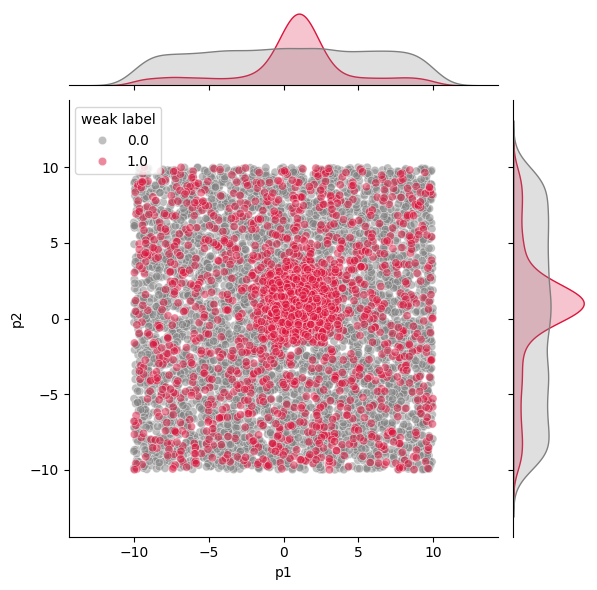

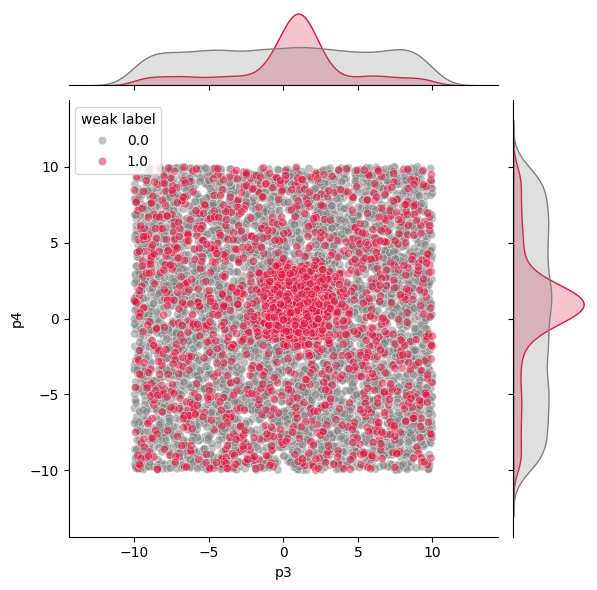

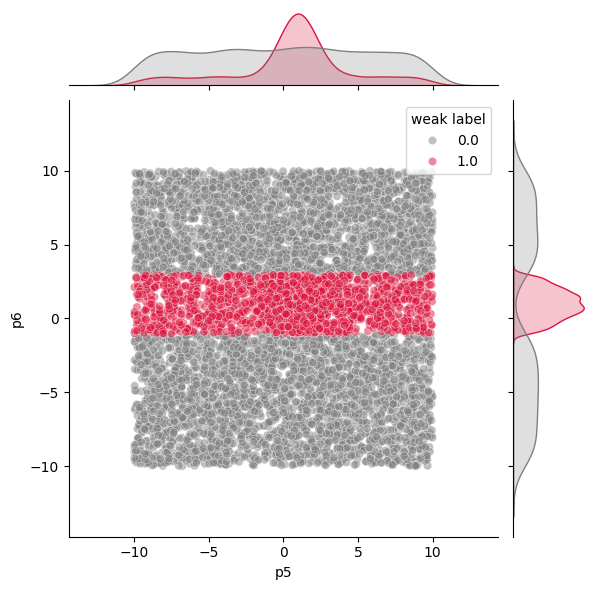

In [9]:
## visualize the regions

df = pd.DataFrame(np.column_stack([X_train_weak, y_train_weak]), columns = ['p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'weak label'])

sns.jointplot(data=df, x="p1", y="p2", hue="weak label", palette={0: "grey", 1: "crimson"}, alpha=0.5)
plt.show()

sns.jointplot(data=df, x="p3", y="p4", hue="weak label", palette={0: "grey", 1: "crimson"}, alpha=0.5)
plt.show()

sns.jointplot(data=df, x="p5", y="p6", hue="weak label", palette={0: "grey", 1: "crimson"}, alpha=0.5)
plt.show()

In [10]:
# define model, CWoLa architecture from https://arxiv.org/pdf/2305.03761

class NeuralNetwork(nn.Module): # class groups variables and functions together
    def __init__(self, input_dim = 5, hidden_dim = 256, output_dim = 1): # create tool, parameters for recalling, call function is used after
        super().__init__() # access all methods, attributes, etc of class
        self.NeuralNetwork = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.2),       
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.2),       
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.2),       
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.NeuralNetwork(x)

In [11]:
# standardize data (if Gaussian shape -- multivariate normal)

### initialize the scaler
scaler = StandardScaler()

### IMPORTANT -- you only want to define your scaling ("fit_transform") based on your training dataset.
X_train_weak_scaled = scaler.fit_transform(X_train_weak)
X_train_weak_scaled_5 = [] # remove 6th parameter from input
for item in X_train_weak_scaled:
    item = item[0:5]
    X_train_weak_scaled_5.append(item)


### Now re-use the same transformation on validation & test sets ("transform")
X_val_weak_scaled   = scaler.transform(X_val_weak)
X_val_weak_scaled_5 = []
for item in X_val_weak_scaled:
    item = item[0:5]
    X_val_weak_scaled_5.append(item)

X_test_weak_scaled  = scaler.transform(X_test_weak)
X_test_weak_scaled_5 = []
for item in X_test_weak_scaled:
    item = item[0:5]
    X_test_weak_scaled_5.append(item)

print("Train mean (before scaling):", np.array(X_train_weak.mean(axis=0)))
print("Train mean (after scaling) -- each dimension should be close to 0:", X_train_weak_scaled.mean(axis=0))
print("Train std (before scaling)", np.array(X_train_weak.std(axis=0)))
print("Train std (after scaling) -- each dimension should be close to 1:", X_train_weak_scaled.std(axis=0))

Train mean (before scaling): [0.3030891  0.17135385 0.19846502 0.18320632 0.18997982 0.22738639]
Train mean (after scaling) -- each dimension should be close to 0: [-2.4531502e-08  4.0367247e-08  1.9758939e-08  1.7419458e-08
  8.6605546e-08 -3.4407247e-08]
Train std (before scaling) [5.1258497 5.241096  5.2272835 5.1734643 5.186646  5.2003303]
Train std (after scaling) -- each dimension should be close to 1: [0.9999999  0.9999997  0.9999994  1.0000004  0.9999998  0.99999905]


In [12]:
# create data tensors and data loaders

X_train_weak_scaled_tensor = torch.tensor(np.array(X_train_weak_scaled_5))
y_train_weak_tensor = torch.tensor(y_train_weak)

X_val_weak_scaled_tensor = torch.tensor(np.array(X_val_weak_scaled_5))
y_val_weak_tensor = torch.tensor(y_val_weak)

X_test_weak_scaled_tensor = torch.tensor(np.array(X_test_weak_scaled_5))
y_test_weak_tensor = torch.tensor(y_test_weak)

train_weak_dataset = TensorDataset(X_train_weak_scaled_tensor, y_train_weak_tensor)
val_weak_dataset = TensorDataset(X_val_weak_scaled_tensor, y_val_weak_tensor)
test_weak_dataset = TensorDataset(X_test_weak_scaled_tensor, y_test_weak_tensor)

train_loader = DataLoader(train_weak_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_weak_dataset, batch_size =16, shuffle=False)
test_loader = DataLoader(test_weak_dataset, batch_size=16, shuffle=False)

for inputs, labels in train_loader:
    print(inputs.shape, labels.shape)
    break
print(len(train_loader)) # should be 8000/16=500

torch.Size([16, 5]) torch.Size([16, 1])
500


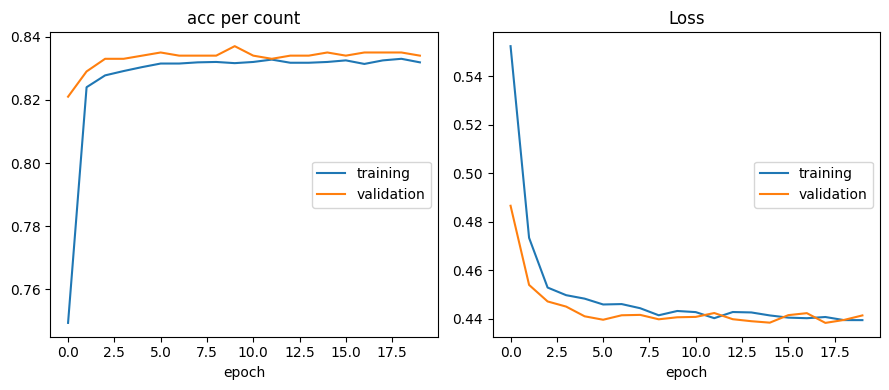

acc per count
	training         	 (min:    0.749, max:    0.833, cur:    0.832)
	validation       	 (min:    0.821, max:    0.837, cur:    0.834)
Loss
	training         	 (min:    0.440, max:    0.552, cur:    0.440)
	validation       	 (min:    0.438, max:    0.487, cur:    0.441)
Epoch 19, Loss: 0.6110396981239319
Epoch 19, Accuracy: 0.834


In [13]:
# train and validate, plot loss and accuracy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # requires previous check for gpu
print(f'Using device: {device}')

# initialize model, loss function, optimizer
model = NeuralNetwork(input_dim = 5, hidden_dim = 256, output_dim = 1).to(device)
loss_fn = nn.BCELoss() # common loss function for multi-class classification problems
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) # default learning rate for Adam optimizer is 0.001

from livelossplot import PlotLosses
liveloss = PlotLosses(figsize=(9,4))

# import wandb
# wandb.init(project='watch-weights')

logs = {}

for epoch in range(20):  # loop over the dataset multiple times (overfitting at 50 epochs)

    # training
    model.train()
    total_train_loss = 0
    train_acc, count = 0.0, 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # zero the parameter gradients, updates weights only on the mini batch
        inputs, labels = inputs.to(device), labels.to(device)
        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss

        loss.backward()  # backward pass
        optimizer.step()  # update parameters
        total_train_loss += loss.item()

        predictions = (out > 0.5).float()
        train_acc += (predictions == labels).sum().item()
        count += labels.size(0)

    train_loss_per_batch = total_train_loss / len(train_loader)
    logs['loss'] = train_loss_per_batch

    train_count_accuracy = train_acc / count
    logs['acc per count'] = train_count_accuracy


    # validation
    model.eval()
    total_val_loss = 0
    val_acc, count = 0.0, 0
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss
        total_val_loss += loss.item()

        predictions = (out > 0.5).float()
        val_acc += (predictions == labels).sum().item()
        count += labels.size(0)

    val_loss_per_batch = total_val_loss / len(val_loader)
    logs['val_loss'] = val_loss_per_batch

    val_count_accuracy = val_acc / count
    logs['val_acc per count'] = val_count_accuracy

    liveloss.update(logs)
    liveloss.send()
    print(f'Epoch {epoch}, Loss: {loss.item()}')
    print(f'Epoch {epoch}, Accuracy: {val_count_accuracy}')

#     wandb.log({"train_loss": train_loss_per_batch, "val_loss": val_loss_per_batch, "epoch": epoch})


# wandb.finish()

Length of Assigned Scores:  8
Assigned Scores:  tensor([[0.2889],
        [0.2223],
        [0.9712],
        [0.1825],
        [0.2002],
        [0.1678],
        [0.9767],
        [0.1592]], device='cuda:0')
Length of Signal/Region Labels:  8
Signal/Region Labels:  tensor([[0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.]], device='cuda:0')
Average test loss: 0.4508 | Test accuracy: 0.829


(array([378., 411.,   4.,   3.,   1.,   1.,   1.,   1.,   6., 194.]),
 array([0.12242813, 0.20856225, 0.29469639, 0.38083053, 0.46696466,
        0.5530988 , 0.63923293, 0.72536707, 0.8115012 , 0.89763534,
        0.98376948]),
 <BarContainer object of 10 artists>)

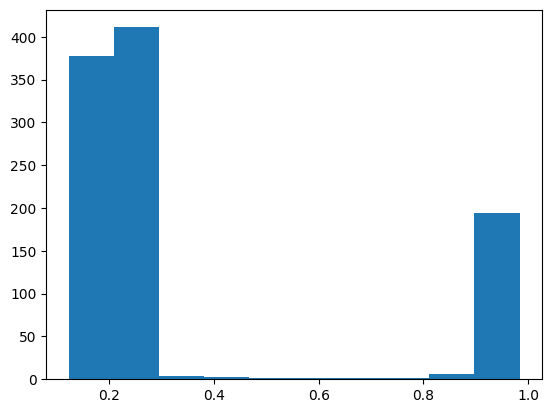

In [14]:
# run on test set, calculate AUC-ROC, list purity and completeness? ### fully supervised, labels are regions

model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_scores = []
all_labels = []
all_out = []

with torch.no_grad():
    for inputs, labels in test_loader:
        
        inputs = inputs.to(device).float()
        labels = labels.to(device).float()
    
        out = model(inputs)
        all_out.extend(out.squeeze().cpu().numpy())
        loss = loss_fn(out, labels)
        test_loss += loss.item() * inputs.size(0)

        scores = (out > 0.5).float()
        all_scores.extend(scores.squeeze().cpu().numpy())
        all_labels.extend(labels.squeeze().cpu().numpy())
            
        # Track counts
        test_acc += (scores == labels).sum().item()
        count += labels.size(0)

print('Length of Assigned Scores: ', len(out))
print('Assigned Scores: ', out)
print('Length of Signal/Region Labels: ', len(scores))
print('Signal/Region Labels: ', scores)

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

plt.hist(all_out)

In [15]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(all_labels, all_scores)
print(f"Test ROC-AUC (vs true labels): {auc:.3f}  (0.5 = no separation, 1.0 = perfect)")

Test ROC-AUC (vs true labels): 0.762  (0.5 = no separation, 1.0 = perfect)


In [16]:
## calculate purity and completeness given signal as a "stream"

## purity: percentage of model selected stars that are truly a part of the stream




## completeness: percentage of stream in that patch that was accurately labeled






# ------------------------------------------------------------------------

### Now test the limits of the CWoLa methodology on the toy dataset

In [ ]:
# testing already trained model on new data, test sets only

In [17]:
# no signal -- inuition says that the model should fail (no anomaly to detect)

background_events = 2000 # 100% background, 0% signal
signal_events = 0 

# background distribution
X_nosig_test = np.random.uniform(low=-10, high=10, size=(background_events, 6))
X_nosig_test = np.array(X_nosig_test, dtype=np.float32)
y_nosig_test = np.zeros((len(X_nosig_test), 1), dtype=np.float32)

idx = np.random.permutation(len(X_nosig_test))
X_nosig_test = X_nosig_test[idx]
y_nosig_test = y_nosig_test[idx]


# standardize
scaler = StandardScaler()
X_nosig_test_scaled = scaler.fit_transform(X_nosig_test)
X_nosig_test_scaled_5 = [] # remove 6th parameter from input
for item in X_nosig_test_scaled:
    item = item[0:5]
    X_nosig_test_scaled_5.append(item)

print("Test mean (before scaling):", np.array(X_nosig_test.mean(axis=0)))
print("Test mean (after scaling) -- each dimension should be close to 0:", X_nosig_test_scaled.mean(axis=0))
print("Test std (before scaling)", np.array(X_nosig_test.std(axis=0)))
print("Test std (after scaling) -- each dimension should be close to 1:", X_nosig_test_scaled.std(axis=0))


X_nosig_test_scaled_tensor = torch.tensor(np.array(X_nosig_test_scaled_5))
y_nosig_test_tensor = torch.tensor(y_nosig_test)

nosig_test_dataset = TensorDataset(X_nosig_test_scaled_tensor, y_nosig_test_tensor)

nosig_test_loader = DataLoader(nosig_test_dataset, batch_size=16, shuffle=False)

for inputs, labels in nosig_test_loader:
    print(inputs.shape, labels.shape)
    break
print(len(nosig_test_loader))

NotFittedError: This StandardScaler instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

Length of Assigned Scores:  16
Assigned Scores:  tensor([[0.2383],
        [0.1988],
        [0.2261],
        [0.1963],
        [0.1795],
        [0.5709],
        [0.2381],
        [0.1889],
        [0.2265],
        [0.2311],
        [0.2354],
        [0.2131],
        [0.2734],
        [0.2602],
        [0.2232],
        [0.1798]], device='cuda:0')
Length of Signal/Region Labels:  16
Signal/Region Labels:  tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0')
Average test loss: 0.2606 | Test accuracy: 0.991


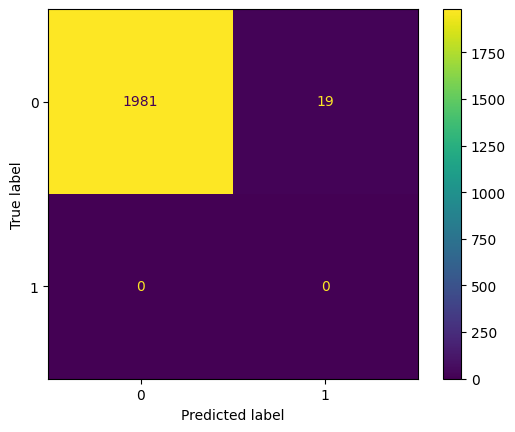

(array([ 557., 1400.,   12.,    8.,    6.,    3.,    3.,    4.,    4.,
           3.]),
 array([0.12390078, 0.20433106, 0.28476134, 0.36519161, 0.44562188,
        0.52605218, 0.60648245, 0.68691272, 0.76734298, 0.84777325,
        0.92820352]),
 <BarContainer object of 10 artists>)

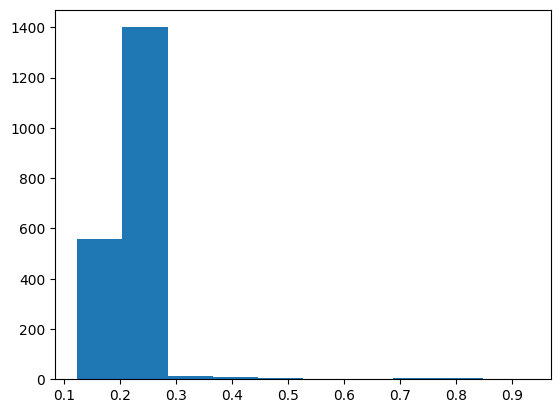

In [ ]:
model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_scores = []
all_labels = []
all_out = []

with torch.no_grad():
    for inputs, labels in nosig_test_loader:
        
        inputs = inputs.to(device).float()
        labels = labels.to(device).float()
    
        out = model(inputs)
        all_out.extend(out.squeeze().cpu().numpy())
        loss = loss_fn(out, labels)
        test_loss += loss.item() * inputs.size(0)

        scores = (out > 0.5).float()
        all_scores.extend(scores.squeeze().cpu().numpy())
        all_labels.extend(labels.squeeze().cpu().numpy())
            
        # Track counts
        test_acc += (scores == labels).sum().item()
        count += labels.size(0)

print('Length of Assigned Scores: ', len(out))
print('Assigned Scores: ', out)
print('Length of Signal/Region Labels: ', len(scores))
print('Signal/Region Labels: ', scores)

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

# confusion matrix, compares predicted labels with actual labels
# columns = predicted classes, rows = actual classes

cm = confusion_matrix(all_labels, all_scores)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()
plt.show()

plt.hist(all_out)

In [ ]:
# 50/50 signal background

background_events = 1000 # 50% background, 50% signal
signal_events = 1000

# background distribution
X_50b_test = np.random.uniform(low=-10, high=10, size=(background_events, 6))
X_50b_test = np.array(X_50b_test, dtype=np.float32)
y_50b_test = np.zeros((len(X_50b_test), 1), dtype=np.float32)


# signal distribution
mu_s = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
cov_s = np.eye(6) # identity matrix for covariance
X_50sig_test = np.random.multivariate_normal(mu_s, cov_s, size=signal_events)
X_50sig_test = np.array(X_50sig_test, dtype=np.float32)
y_50sig_test = np.ones((len(X_50sig_test), 1), dtype=np.float32)

print(f"Background test set has {len(X_50b_test)} events.")
print(f"Signal test set has {len(X_50sig_test)} events.")

X_5050_test = np.vstack([X_50b_test, X_50sig_test])
y_5050_test = np.concatenate([y_50b_test, y_50sig_test])

idx = np.random.permutation(len(X_5050_test))
X_5050_test = X_5050_test[idx]
y_5050_test = y_5050_test[idx]


# standardize
scaler = StandardScaler()
X_5050_test_scaled = scaler.transform(X_5050_test)
X_5050_test_scaled_5 = [] # remove 6th parameter from input
for item in X_5050_test_scaled:
    item = item[0:5]
    X_5050_test_scaled_5.append(item)


X_5050_test_scaled_tensor = torch.tensor(np.array(X_5050_test_scaled_5))
y_5050_test_tensor = torch.tensor(y_5050_test)

test5050_dataset = TensorDataset(X_5050_test_scaled_tensor, y_5050_test_tensor)

test5050_loader = DataLoader(test5050_dataset, batch_size=16, shuffle=False)

Background test set has 1000 events.
Signal test set has 1000 events.


Length of Assigned Scores:  16
Assigned Scores:  tensor([[0.2228],
        [0.2372],
        [0.2322],
        [0.2679],
        [0.1768],
        [0.6244],
        [0.2204],
        [0.8600],
        [0.1480],
        [0.1613],
        [0.9776],
        [0.9504],
        [0.2341],
        [0.9714],
        [0.9056],
        [0.2256]], device='cuda:0')
Length of Signal/Region Labels:  16
Signal/Region Labels:  tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.]], device='cuda:0')
Average test loss: 0.1551 | Test accuracy: 0.996


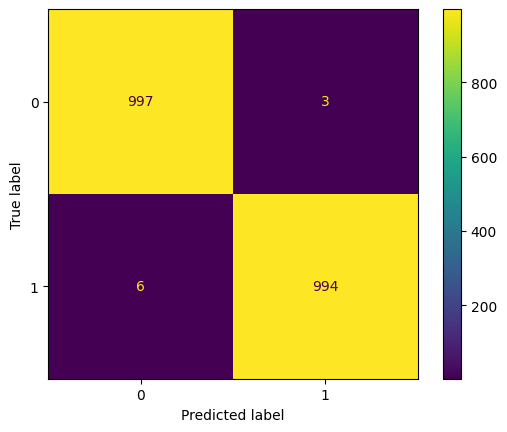

(array([186., 751.,  59.,   4.,   6.,   6.,  14.,  39., 108., 827.]),
 array([0.07634325, 0.16686642, 0.25738961, 0.34791273, 0.43843591,
        0.5289591 , 0.61948222, 0.7100054 , 0.80052859, 0.89105177,
        0.98157489]),
 <BarContainer object of 10 artists>)

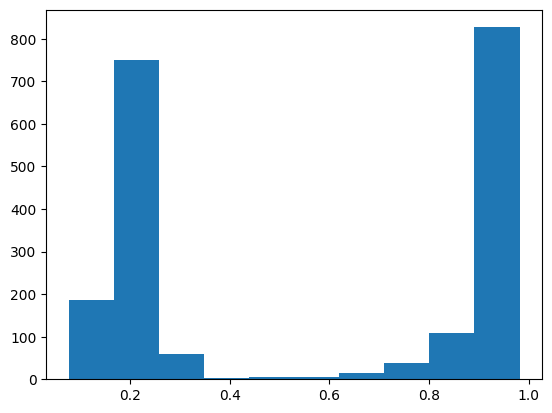

In [ ]:
model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_scores = []
all_labels = []
all_out = []

with torch.no_grad():
    for inputs, labels in test5050_loader:
        
        inputs = inputs.to(device).float()
        labels = labels.to(device).float()
    
        out = model(inputs)
        all_out.extend(out.squeeze().cpu().numpy())
        loss = loss_fn(out, labels)
        test_loss += loss.item() * inputs.size(0)

        scores = (out > 0.5).float()
        all_scores.extend(scores.squeeze().cpu().numpy())
        all_labels.extend(labels.squeeze().cpu().numpy())
            
        # Track counts
        test_acc += (scores == labels).sum().item()
        count += labels.size(0)

print('Length of Assigned Scores: ', len(out))
print('Assigned Scores: ', out)
print('Length of Signal/Region Labels: ', len(scores))
print('Signal/Region Labels: ', scores)

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

# confusion matrix, compares predicted labels with actual labels
# columns = predicted classes, rows = actual classes

cm = confusion_matrix(all_labels, all_scores)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()
plt.show()

plt.hist(all_out)

In [ ]:
# all signal

background_events = 0 # 0% background, 100% signal
signal_events = 2000


# signal distribution
mu_s = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
cov_s = np.eye(6) # identity matrix for covariance
X_allsig_test = np.random.multivariate_normal(mu_s, cov_s, size=signal_events)
X_allsig_test = np.array(X_allsig_test, dtype=np.float32)
y_allsig_test = np.ones((len(X_allsig_test), 1), dtype=np.float32)

print(f"Test set has {len(X_allsig_test)} events.")

idx = np.random.permutation(len(X_allsig_test))
X_allsig_test = X_allsig_test[idx]
y_allsig_test = y_allsig_test[idx]


# standardize
scaler = StandardScaler()
X_allsig_test_scaled = scaler.transform(X_allsig_test)
X_allsig_test_scaled_5 = [] # remove 6th parameter from input
for item in X_allsig_test_scaled:
    item = item[0:5]
    X_allsig_test_scaled_5.append(item)


X_allsig_test_scaled_tensor = torch.tensor(np.array(X_allsig_test_scaled_5))
y_allsig_test_tensor = torch.tensor(y_allsig_test)

allsig_test_dataset = TensorDataset(X_allsig_test_scaled_tensor, y_allsig_test_tensor)

allsig_test_loader = DataLoader(allsig_test_dataset, batch_size=16, shuffle=False)

Test set has 2000 events.


Length of Assigned Scores:  16
Assigned Scores:  tensor([[0.2109],
        [0.2320],
        [0.1164],
        [0.1757],
        [0.1783],
        [0.1709],
        [0.2023],
        [0.2381],
        [0.2093],
        [0.2022],
        [0.2145],
        [0.3612],
        [0.2084],
        [0.1681],
        [0.2606],
        [0.2041]], device='cuda:0')
Length of Signal/Region Labels:  16
Signal/Region Labels:  tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0')
Average test loss: 1.4877 | Test accuracy: 0.032


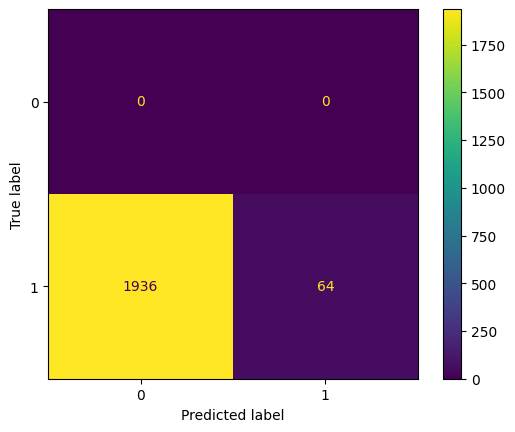

(array([ 180., 1629.,   87.,   30.,   14.,    8.,   20.,   12.,    8.,
          12.]),
 array([0.08685654, 0.17550781, 0.26415908, 0.35281035, 0.44146162,
        0.53011286, 0.61876416, 0.7074154 , 0.7960667 , 0.884718  ,
        0.97336924]),
 <BarContainer object of 10 artists>)

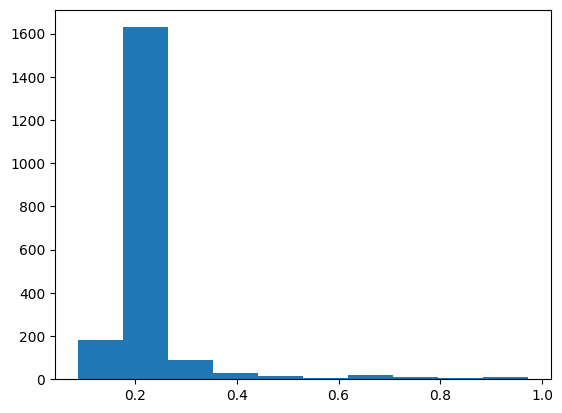

In [ ]:
model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_scores = []
all_labels = []
all_out = []

with torch.no_grad():
    for inputs, labels in allsig_test_loader:
        
        inputs = inputs.to(device).float()
        labels = labels.to(device).float()
    
        out = model(inputs)
        all_out.extend(out.squeeze().cpu().numpy())
        loss = loss_fn(out, labels)
        test_loss += loss.item() * inputs.size(0)

        scores = (out > 0.5).float()
        all_scores.extend(scores.squeeze().cpu().numpy())
        all_labels.extend(labels.squeeze().cpu().numpy())
            
        # Track counts
        test_acc += (scores == labels).sum().item()
        count += labels.size(0)

print('Length of Assigned Scores: ', len(out))
print('Assigned Scores: ', out)
print('Length of Signal/Region Labels: ', len(scores))
print('Signal/Region Labels: ', scores)

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

# confusion matrix, compares predicted labels with actual labels
# columns = predicted classes, rows = actual classes

cm = confusion_matrix(all_labels, all_scores)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()
plt.show()

plt.hist(all_out)

In [ ]:
# signal/background regions not matching data

idx = np.random.permutation(len(X_train))
X_train = X_train[idx]
y_train = y_train[idx]

idx = np.random.permutation(len(X_val))
X_val = X_val[idx]
y_val = y_val[idx]

idx = np.random.permutation(len(X_test))
X_test = X_test[idx]
y_test = y_test[idx]

print(f"Background training set has {len(Xb_train)} events.")
print(f"Background validation set has {len(Xb_val)} events.")
print(f"Background test set has {len(Xb_test)} events.")
print(f"Signal training set has {len(Xs_train)} events.")
print(f"Signal validation set has {len(Xs_val)} events.")
print(f"Signal test set has {len(Xs_test)} events.")

Background training set has 6400 events.
Background validation set has 800 events.
Background test set has 800 events.
Signal training set has 1600 events.
Signal validation set has 200 events.
Signal test set has 200 events.


Signal Parameter p6 median =  0.97594225
Signal Parameter p6 standard deviation =  1.0381874


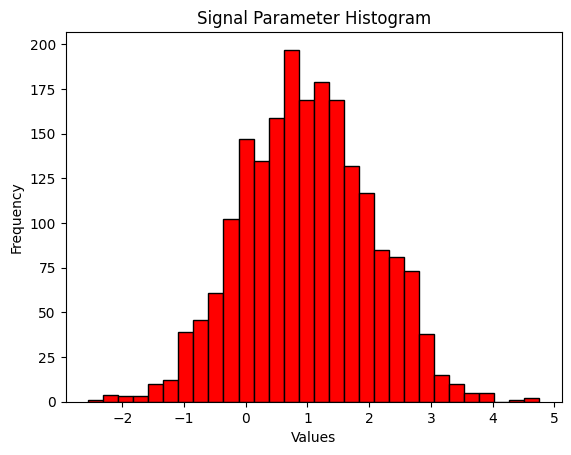

Signal Region Range:  3.0523171  to  7.205066


In [ ]:
# redefine signal and sideband regions

signal_parameter = df_signal['p6']

p6_median = np.median(signal_parameter)
p6_std = np.std(signal_parameter)
print('Signal Parameter p6 median = ', p6_median)
print('Signal Parameter p6 standard deviation = ', p6_std)

plt.hist(signal_parameter, bins=30, color='red', edgecolor='black')
plt.xlabel('Values')
plt.ylabel('Frequency')
plt.title('Signal Parameter Histogram')
plt.show()

# signal region will be defined as 3-5 standard deviations away from the median
sig_reg_low = p6_median + (2 * p6_std)
sig_reg_high = p6_median + (6 * p6_std)
print('Signal Region Range: ', sig_reg_low, ' to ', sig_reg_high)

In [ ]:
# keep test set as is, adjust training and validation sets to have region labels

X_train_background_region = []
X_train_signal_region = []
X_val_background_region = []
X_val_signal_region = []

for event in X_train:
    if event[5] < sig_reg_low or event[5] > sig_reg_high:
        X_train_background_region.append(event)
    else:
        X_train_signal_region.append(event)
for event in X_val:
    if event[5] < sig_reg_low or event[5] > sig_reg_high:
        X_val_background_region.append(event)
    else:
        X_val_signal_region.append(event)

X_train_background_region = np.array(X_train_background_region)
X_train_signal_region = np.array(X_train_signal_region)
X_val_background_region = np.array(X_val_background_region)
X_val_signal_region = np.array(X_val_signal_region)

y_train_background_region = np.zeros((len(X_train_background_region), 1), dtype=np.float32)
y_train_signal_region = np.ones((len(X_train_signal_region), 1), dtype=np.float32)
y_val_background_region = np.zeros((len(X_val_background_region), 1), dtype=np.float32)
y_val_signal_region = np.ones((len(X_val_signal_region), 1), dtype=np.float32)

X_train_weak = np.vstack([X_train_background_region, X_train_signal_region]).astype(np.float32)
X_val_weak = np.vstack([X_val_background_region, X_val_signal_region]).astype(np.float32)
y_train_weak = np.concatenate((y_train_background_region, y_train_signal_region)).astype(np.float32)
y_val_weak = np.concatenate((y_val_background_region, y_val_signal_region)).astype(np.float32)

print(f"Training set has {len(X_train_weak)} events.")
print(f"Validation set has {len(X_val_weak)} events.")
print(f"Test set has {len(X_test)} events.")

Training set has 8000 events.
Validation set has 1000 events.
Test set has 1000 events.


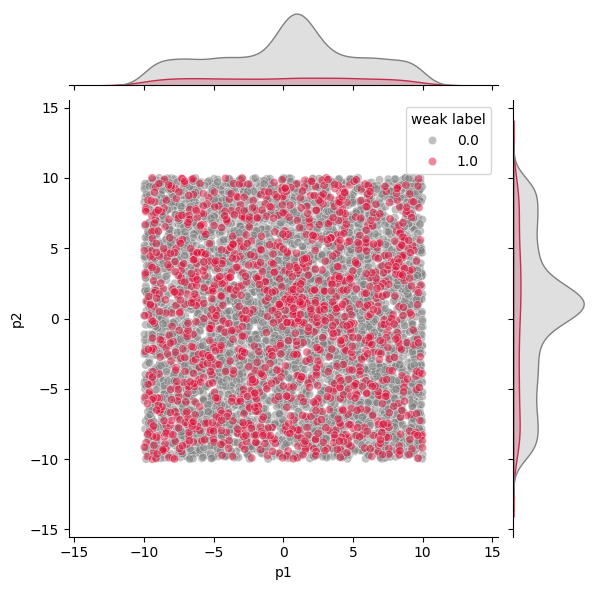

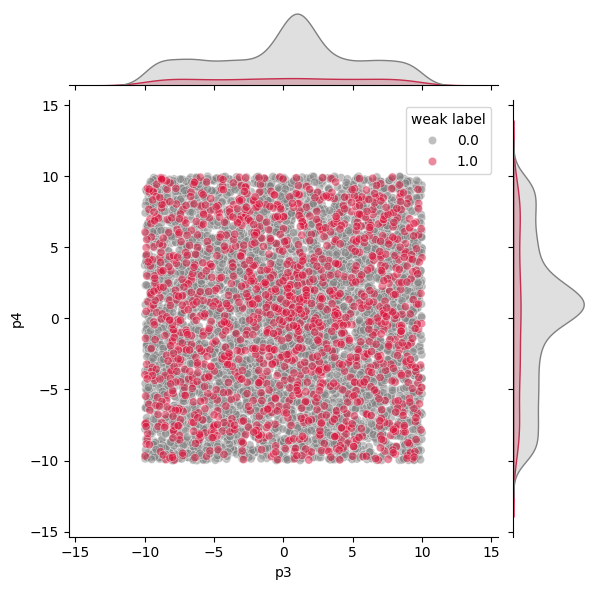

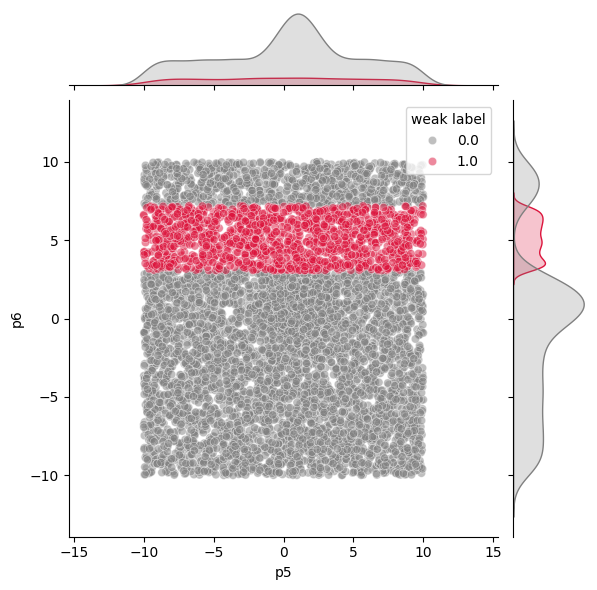

In [ ]:
## visualize the regions

df = pd.DataFrame(np.column_stack([X_train_weak, y_train_weak]), columns = ['p1', 'p2', 'p3', 'p4', 'p5', 'p6', 'weak label'])

sns.jointplot(data=df, x="p1", y="p2", hue="weak label", palette={0: "grey", 1: "crimson"}, alpha=0.5)
plt.show()

sns.jointplot(data=df, x="p3", y="p4", hue="weak label", palette={0: "grey", 1: "crimson"}, alpha=0.5)
plt.show()

sns.jointplot(data=df, x="p5", y="p6", hue="weak label", palette={0: "grey", 1: "crimson"}, alpha=0.5)
plt.show()

In [ ]:
### initialize the scaler
scaler = StandardScaler()

### IMPORTANT -- you only want to define your scaling ("fit_transform") based on your training dataset.
X_train_weak_scaled = scaler.fit_transform(X_train_weak)
X_train_weak_scaled_5 = [] # remove 6th parameter from input
for item in X_train_weak_scaled:
    item = item[0:5]
    X_train_weak_scaled_5.append(item)


### Now re-use the same transformation on validation & test sets ("transform")
X_val_weak_scaled   = scaler.transform(X_val_weak)
X_val_weak_scaled_5 = []
for item in X_val_weak_scaled:
    item = item[0:5]
    X_val_weak_scaled_5.append(item)

X_test_scaled  = scaler.transform(X_test)
X_test_scaled_5 = []
for item in X_test_scaled:
    item = item[0:5]
    X_test_scaled_5.append(item)


print("Train mean (before scaling):", np.array(X_train_weak.mean(axis=0)))
print("Train mean (after scaling) -- each dimension should be close to 0:", X_train_weak_scaled.mean(axis=0))
print("Train std (before scaling)", np.array(X_train_weak.std(axis=0)))
print("Train std (after scaling) -- each dimension should be close to 1:", X_train_weak_scaled.std(axis=0))

Train mean (before scaling): [0.1848504  0.21620949 0.12404823 0.11072146 0.15244366 0.12622441]
Train mean (after scaling) -- each dimension should be close to 0: [-4.2364000e-08  2.1249056e-08  8.7916847e-09  2.6971101e-09
 -5.7987869e-08  2.5852771e-07]
Train std (before scaling) [5.2108593 5.21236   5.226135  5.1584973 5.1693816 5.222364 ]
Train std (after scaling) -- each dimension should be close to 1: [1.         0.9999992  0.99999964 1.0000008  1.0000001  0.9999999 ]


In [ ]:
# create data tensors and data loaders

X_train_weak_scaled_tensor = torch.tensor(np.array(X_train_weak_scaled_5))
y_train_weak_tensor = torch.tensor(y_train_weak)

X_val_weak_scaled_tensor = torch.tensor(np.array(X_val_weak_scaled_5))
y_val_weak_tensor = torch.tensor(y_val_weak)

X_test_scaled_tensor = torch.tensor(np.array(X_test_scaled_5))
y_test_tensor = torch.tensor(y_test)

train_weak_dataset = TensorDataset(X_train_weak_scaled_tensor, y_train_weak_tensor)
val_weak_dataset = TensorDataset(X_val_weak_scaled_tensor, y_val_weak_tensor)
test_dataset = TensorDataset(X_test_scaled_tensor, y_test_tensor)

train_loader = DataLoader(train_weak_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_weak_dataset, batch_size =16, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

for inputs, labels in train_loader:
    print(inputs.shape, labels.shape)
    break
print(len(train_loader))

torch.Size([16, 5]) torch.Size([16, 1])
500


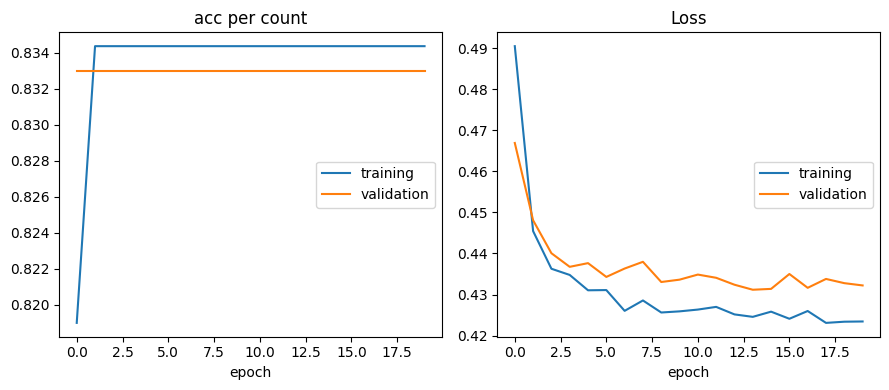

acc per count
	training         	 (min:    0.819, max:    0.834, cur:    0.834)
	validation       	 (min:    0.833, max:    0.833, cur:    0.833)
Loss
	training         	 (min:    0.423, max:    0.491, cur:    0.423)
	validation       	 (min:    0.431, max:    0.467, cur:    0.432)
Epoch 19, Loss: 1.581661343574524
Epoch 19, Accuracy: 0.833


In [ ]:
# train and validate, plot loss and accuracy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # requires previous check for gpu
print(f'Using device: {device}')

# initialize model, loss function, optimizer
model = NeuralNetwork(input_dim = 5, hidden_dim = 256, output_dim = 1).to(device)
loss_fn = nn.BCELoss() # common loss function for multi-class classification problems
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) # default learning rate for Adam optimizer is 0.001

from livelossplot import PlotLosses
liveloss = PlotLosses(figsize=(9,4))

# import wandb
# wandb.init(project='watch-weights')

logs = {}

for epoch in range(20):  # loop over the dataset multiple times (overfitting at 50 epochs)

    # training
    model.train()
    total_train_loss = 0
    train_acc, count = 0.0, 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()  # zero the parameter gradients, updates weights only on the mini batch
        inputs, labels = inputs.to(device), labels.to(device)
        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss

        loss.backward()  # backward pass
        optimizer.step()  # update parameters
        total_train_loss += loss.item()

        predictions = (out > 0.5).float()
        train_acc += (predictions == labels).sum().item()
        count += labels.size(0)

    train_loss_per_batch = total_train_loss / len(train_loader)
    logs['loss'] = train_loss_per_batch

    train_count_accuracy = train_acc / count
    logs['acc per count'] = train_count_accuracy


    # validation
    model.eval()
    total_val_loss = 0
    val_acc, count = 0.0, 0
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        out = model(inputs)  # forward pass
        loss = loss_fn(out, labels)  # compute loss
        total_val_loss += loss.item()

        predictions = (out > 0.5).float()
        val_acc += (predictions == labels).sum().item()
        count += labels.size(0)

    val_loss_per_batch = total_val_loss / len(val_loader)
    logs['val_loss'] = val_loss_per_batch

    val_count_accuracy = val_acc / count
    logs['val_acc per count'] = val_count_accuracy

    liveloss.update(logs)
    liveloss.send()
    print(f'Epoch {epoch}, Loss: {loss.item()}')
    print(f'Epoch {epoch}, Accuracy: {val_count_accuracy}')

#     wandb.log({"train_loss": train_loss_per_batch, "val_loss": val_loss_per_batch, "epoch": epoch})


# wandb.finish()

Length of Assigned Scores:  8
Assigned Scores:  tensor([[0.1954],
        [0.2537],
        [0.2251],
        [0.1606],
        [0.0254],
        [0.1832],
        [0.1957],
        [0.2060]], device='cuda:0')
Length of Signal/Region Labels:  8
Signal/Region Labels:  tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]], device='cuda:0')
Average test loss: 0.9096 | Test accuracy: 0.800


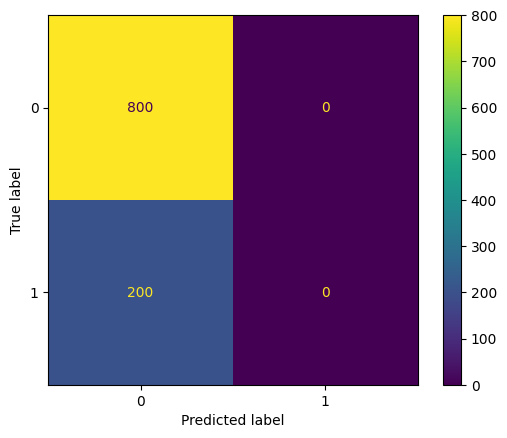

(array([194.,   6.,   6.,  19.,  97., 218., 260., 129.,  56.,  15.]),
 array([0.01796621, 0.04993536, 0.08190451, 0.11387366, 0.14584281,
        0.17781195, 0.20978111, 0.24175026, 0.2737194 , 0.30568856,
        0.33765769]),
 <BarContainer object of 10 artists>)

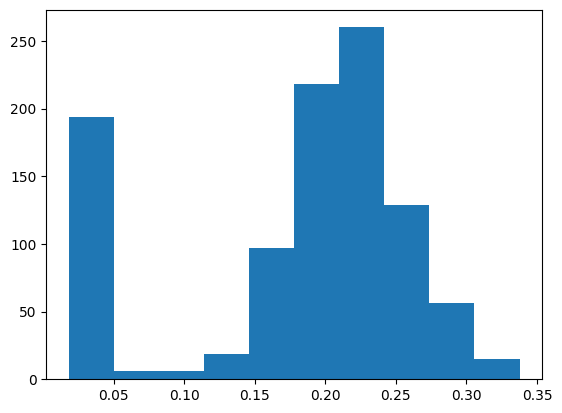

In [ ]:
model.eval()
test_loss, test_acc, count = 0.0, 0.0, 0
all_scores = []
all_labels = []
all_out = []

with torch.no_grad():
    for inputs, labels in test_loader:
        
        inputs = inputs.to(device).float()
        labels = labels.to(device).float()
    
        out = model(inputs)
        all_out.extend(out.squeeze().cpu().numpy())
        loss = loss_fn(out, labels)
        test_loss += loss.item() * inputs.size(0)

        scores = (out > 0.5).float()
        all_scores.extend(scores.squeeze().cpu().numpy())
        all_labels.extend(labels.squeeze().cpu().numpy())
            
        # Track counts
        test_acc += (scores == labels).sum().item()
        count += labels.size(0)

print('Length of Assigned Scores: ', len(out))
print('Assigned Scores: ', out)
print('Length of Signal/Region Labels: ', len(scores))
print('Signal/Region Labels: ', scores)

all_scores = np.array(all_scores)
all_labels = np.array(all_labels)

print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

# confusion matrix, compares predicted labels with actual labels
# columns = predicted classes, rows = actual classes

cm = confusion_matrix(all_labels, all_scores)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm)
cm_display.plot()
plt.show()

plt.hist(all_out)

In [ ]:
### OBSERVATIONS

# no signal: worked, assumed all is background
# all signal: broke, makes sense to assume all is background (no anomaly)
# signal band defined elsewhere: model guessed all background and therefore got 80% accuracy

In [ ]:
# og code from toydatasettests

def toy_data(total_events, background_fraction, signal_fraction): 
    background_events = int(total_events * background_fraction)
    signal_events = int(total_events * signal_fraction)

    # background distribution
    Xb = np.random.uniform(low=-10, high=10, size=(background_events, 6))
    Xb = np.array(Xb, dtype=np.float32)
    yb = np.zeros((len(Xb), 1), dtype=np.float32)
    # 80% train, 10% val, 10% test
    Xb_train, Xb_valtest, yb_train, yb_valtest = train_test_split(Xb, yb, test_size = 0.2) 
    Xb_val, Xb_test, yb_val, yb_test = train_test_split(Xb_valtest, yb_valtest, test_size = 0.5)

    # signal distribution
    mu_s = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0])
    cov_s = np.eye(6) # identity matrix for covariance
    Xs = np.random.multivariate_normal(mu_s, cov_s, size=signal_events)
    Xs = np.array(Xs, dtype=np.float32)
    ys = np.ones((len(Xs), 1), dtype=np.float32)
    # 80% train, 10% val, 10% test
    Xs_train, Xs_valtest, ys_train, ys_valtest = train_test_split(Xs, ys, test_size = 0.2)
    Xs_val, Xs_test, ys_val, ys_test = train_test_split(Xs_valtest, ys_valtest, test_size=0.5)

    # guarantees that training, validation, and test have the same percentage of background vs signal points
    print(f"Background training set has {len(Xb_train)} events.")
    print(f"Background validation set has {len(Xb_val)} events.")
    print(f"Background test set has {len(Xb_test)} events.")
    print(f"Signal training set has {len(Xs_train)} events.")
    print(f"Signal validation set has {len(Xs_val)} events.")
    print(f"Signal test set has {len(Xs_test)} events.")

    X_train = np.vstack([Xb_train, Xs_train])
    X_val = np.vstack([Xb_val, Xs_val])
    X_test = np.vstack([Xb_test, Xs_test])
    y_train = np.concatenate([yb_train, ys_train])
    y_val = np.concatenate([yb_val, ys_val])
    y_test = np.concatenate([yb_test, ys_test])

    idx = np.random.permutation(len(X_train))
    X_train = X_train[idx]
    y_train = y_train[idx]

    idx = np.random.permutation(len(X_val))
    X_val = X_val[idx]
    y_val = y_val[idx]

    idx = np.random.permutation(len(X_test))
    X_test = X_test[idx]
    y_test = y_test[idx]

    df_signal = pd.DataFrame(Xs, columns=['p1', 'p2', 'p3', 'p4', 'p5', 'p6'])
    signal_parameter = df_signal['p6']

    p6_median = np.median(signal_parameter)
    p6_std = np.std(signal_parameter)
    print('Signal Parameter p6 median = ', p6_median)
    print('Signal Parameter p6 standard deviation = ', p6_std)

    # signal region will be defined as 1 standard deviation away from the median
    sig_reg_low = p6_median - (1 * p6_std)
    sig_reg_high = p6_median + (1 * p6_std)
    print('Signal Region Range: ', sig_reg_low, ' to ', sig_reg_high)


    X_train_background_region = []
    X_train_signal_region = []
    X_val_background_region = []
    X_val_signal_region = []
    X_test_background_region = []
    X_test_signal_region = []

    for event in X_train:
        if event[5] < sig_reg_low or event[5] > sig_reg_high:
            X_train_background_region.append(event)
        else:
            X_train_signal_region.append(event)
    for event in X_val:
        if event[5] < sig_reg_low or event[5] > sig_reg_high:
            X_val_background_region.append(event)
        else:
            X_val_signal_region.append(event)
    for event in X_test:
        if event[5] < sig_reg_low or event[5] > sig_reg_high:
            X_test_background_region.append(event)
        else:
            X_test_signal_region.append(event)

    X_train_background_region = np.array(X_train_background_region)
    X_train_signal_region = np.array(X_train_signal_region)
    X_val_background_region = np.array(X_val_background_region)
    X_val_signal_region = np.array(X_val_signal_region)
    X_test_background_region = np.array(X_test_background_region)
    X_test_signal_region = np.array(X_test_signal_region)

    y_train_background_region = np.zeros((len(X_train_background_region), 1), dtype=np.float32)
    y_train_signal_region = np.ones((len(X_train_signal_region), 1), dtype=np.float32)
    y_val_background_region = np.zeros((len(X_val_background_region), 1), dtype=np.float32)
    y_val_signal_region = np.ones((len(X_val_signal_region), 1), dtype=np.float32)
    y_test_background_region = np.zeros((len(X_val_background_region), 1), dtype=np.float32)
    y_test_signal_region = np.ones((len(X_val_signal_region), 1), dtype=np.float32)

    X_train = np.vstack([X_train_background_region, X_train_signal_region]).astype(np.float32)
    X_val = np.vstack([X_val_background_region, X_val_signal_region]).astype(np.float32)
    y_train = np.concatenate((y_train_background_region, y_train_signal_region)).astype(np.float32)
    y_val = np.concatenate((y_val_background_region, y_val_signal_region)).astype(np.float32)
    X_test = np.vstack([X_test_background_region, X_test_signal_region]).astype(np.float32)
    y_test = np.concatenate((y_test_background_region, y_test_signal_region)).astype(np.float32)

    print(f"Training set has {len(X_train)} events.")
    print(f"Validation set has {len(X_val)} events.")
    print(f"Test set has {len(X_test)} events.")

    return X_train, y_train, X_val, y_val, X_test, y_test

In [ ]:
class NeuralNetwork(nn.Module): # class groups variables and functions together
    def __init__(self, input_dim = 5, hidden_dim = 256, output_dim = 1): # create tool, parameters for recalling, call function is used after
        super().__init__() # access all methods, attributes, etc of class
        self.NeuralNetwork = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.2),       
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.2),       
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(p=0.2),       
            nn.Linear(hidden_dim, output_dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.NeuralNetwork(x)

def train(X_train, y_train, X_val, y_val, X_test, y_test):
    liveloss = PlotLosses(figsize=(9,4))
    
    ### initialize the scaler
    scaler = StandardScaler()

    ### IMPORTANT -- you only want to define your scaling ("fit_transform") based on your training dataset.
    X_train_scaled = scaler.fit_transform(X_train)
    X_train_scaled_5 = [] # remove 6th parameter from input
    for item in X_train_scaled:
        item = item[0:5]
        X_train_scaled_5.append(item)

    ### Now re-use the same transformation on validation & test sets ("transform")
    X_val_scaled   = scaler.transform(X_val)
    X_val_scaled_5 = []
    for item in X_val_scaled:
        item = item[0:5]
        X_val_scaled_5.append(item)

    X_test_scaled  = scaler.transform(X_test)
    X_test_scaled_5 = []
    for item in X_test_scaled:
        item = item[0:5]
        X_test_scaled_5.append(item)

    print("Train mean (before scaling):", np.array(X_train.mean(axis=0)))
    print("Train mean (after scaling) -- each dimension should be close to 0:", X_train_scaled.mean(axis=0))
    print("Train std (before scaling)", np.array(X_train.std(axis=0)))
    print("Train std (after scaling) -- each dimension should be close to 1:", X_train_scaled.std(axis=0))

    X_train_scaled_tensor = torch.tensor(np.array(X_train_scaled_5))
    y_train_tensor = torch.tensor(y_train)

    X_val_scaled_tensor = torch.tensor(np.array(X_val_scaled_5))
    y_val_tensor = torch.tensor(y_val)

    X_test_scaled_tensor = torch.tensor(np.array(X_test_scaled_5))
    y_test_tensor = torch.tensor(y_test)

    train_dataset = TensorDataset(X_train_scaled_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_scaled_tensor, y_val_tensor)
    test_dataset = TensorDataset(X_test_scaled_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size =16, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    for inputs, labels in train_loader:
        print(inputs.shape, labels.shape)
        break

    # train and validate, plot loss and accuracy

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # requires previous check for gpu
    print(f'Using device: {device}')

    # initialize model, loss function, optimizer
    model = NeuralNetwork(input_dim = 5, hidden_dim = 256, output_dim = 1).to(device)
    loss_fn = nn.BCELoss() # common loss function for multi-class classification problems
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001) # default learning rate for Adam optimizer is 0.001

    logs = {}

    for epoch in range(20):  # loop over the dataset multiple times (overfitting at 50 epochs)

        # training
        model.train()
        total_train_loss = 0
        train_acc, count = 0.0, 0
        for inputs, labels in train_loader:
            optimizer.zero_grad()  # zero the parameter gradients, updates weights only on the mini batch
            inputs, labels = inputs.to(device), labels.to(device)
            out = model(inputs)  # forward pass
            loss = loss_fn(out, labels)  # compute loss

            loss.backward()  # backward pass
            optimizer.step()  # update parameters
            total_train_loss += loss.item()

            predictions = (out > 0.5).float()
            train_acc += (predictions == labels).sum().item()
            count += labels.size(0)

        train_loss_per_batch = total_train_loss / len(train_loader)
        logs['loss'] = train_loss_per_batch

        train_count_accuracy = train_acc / count
        logs['acc per count'] = train_count_accuracy


        # validation
        model.eval()
        total_val_loss = 0
        val_acc, count = 0.0, 0
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            out = model(inputs)  # forward pass
            loss = loss_fn(out, labels)  # compute loss
            total_val_loss += loss.item()

            predictions = (out > 0.5).float()
            val_acc += (predictions == labels).sum().item()
            count += labels.size(0)

        val_loss_per_batch = total_val_loss / len(val_loader)
        logs['val_loss'] = val_loss_per_batch

        val_count_accuracy = val_acc / count
        logs['val_acc per count'] = val_count_accuracy

        liveloss.update(logs)
        liveloss.send()
        print(f'Epoch {epoch}, Loss: {loss.item()}')
        print(f'Epoch {epoch}, Accuracy: {val_count_accuracy}')

    # run on test set

    model.eval()
    test_loss, test_acc, count = 0.0, 0.0, 0
    all_scores = []
    all_labels = []
    all_out = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            
            inputs = inputs.to(device).float()
            labels = labels.to(device).float()
        
            out = model(inputs)
            all_out.extend(out.squeeze().cpu().numpy())
            loss = loss_fn(out, labels)
            test_loss += loss.item() * inputs.size(0)

            scores = (out > 0.5).float()
            all_scores.extend(scores.squeeze().cpu().numpy())
            all_labels.extend(labels.squeeze().cpu().numpy())
                
            # Track counts
            test_acc += (scores == labels).sum().item()
            count += labels.size(0)

    print('Length of Assigned Scores: ', len(out))
    print('Assigned Scores: ', out)
    print('Length of Signal/Region Labels: ', len(scores))
    print('Signal/Region Labels: ', scores)

    all_scores = np.array(all_scores)
    all_labels = np.array(all_labels)

    print(f"Average test loss: {test_loss/count:.4f} | Test accuracy: {test_acc/count:.3f}")

    plt.hist(all_out)

    auc = roc_auc_score(all_labels, all_scores)
    print(f"Test ROC-AUC (vs true labels): {auc:.3f}  (0.5 = no separation, 1.0 = perfect)")